Generated: 4 holograms


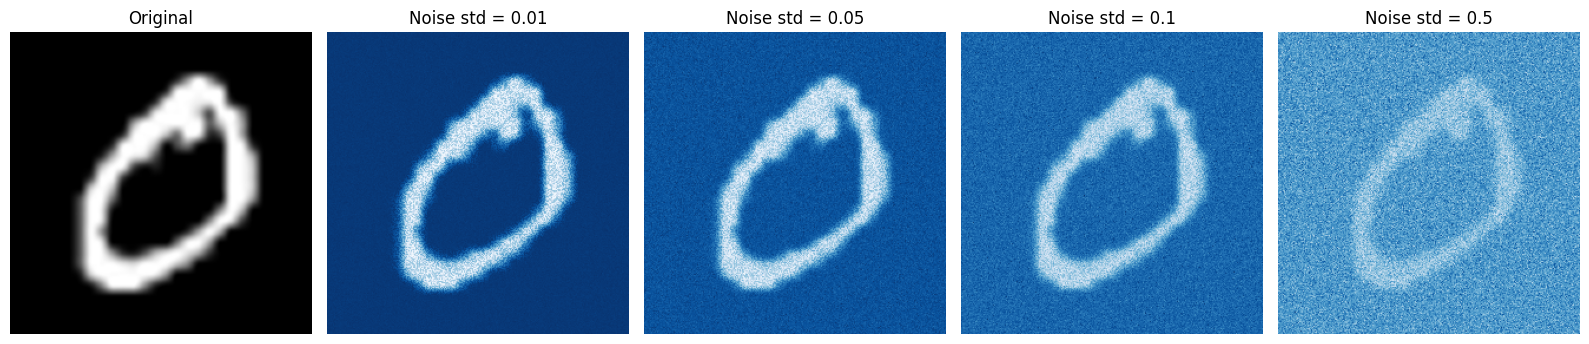

In [ ]:
import torch
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms


def simulate_qiup_hologram(amplitude,
                           rp=0.5,
                           ri=0.5,
                           gamma=0.5,
                           noise_std_list=[0.01, 0.05, 0.1, 0.5]):

    phi = torch.rand_like(amplitude) * (2 * math.pi)
    rs = amplitude

    base_holo = rp**2 + rs**2 + 2 * rp * rs * ri * gamma * torch.cos(phi)

    holograms = []

    for std in noise_std_list:
        created_noise = std * torch.randn_like(base_holo)
        noisy_holo = base_holo + created_noise

        noisy_holo = (noisy_holo - noisy_holo.min()) / (noisy_holo.max() - noisy_holo.min() + 1e-8)

        holograms.append(noisy_holo)

    return holograms


img = Image.open("smooth0.png").convert("L")

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

amp = transform(img)

noise_levels = [0.01, 0.05, 0.1, 0.5]
holograms = simulate_qiup_hologram(amp, noise_std_list=noise_levels)

print("Generated:", len(holograms), "holograms")


plt.figure(figsize=(16, 5))

# original
plt.subplot(1, 5, 1)
plt.title("Original")
plt.imshow(amp.squeeze(), cmap="gray")
plt.axis("off")

# noisy holograms
for i, (holo, n) in enumerate(zip(holograms, noise_levels)):
    plt.subplot(1, 5, i+2)
    plt.title(f"Noise std = {n}")
    plt.imshow(holo.squeeze(), cmap="Blues_r")
    plt.axis("off")

plt.tight_layout()
plt.show()


for n, holo in zip(noise_levels, holograms):
    holo_np = (holo.squeeze().numpy() * 255).astype(np.uint8)
    Image.fromarray(holo_np).save(f"hologram_noise_{n}.png")


## random chioce

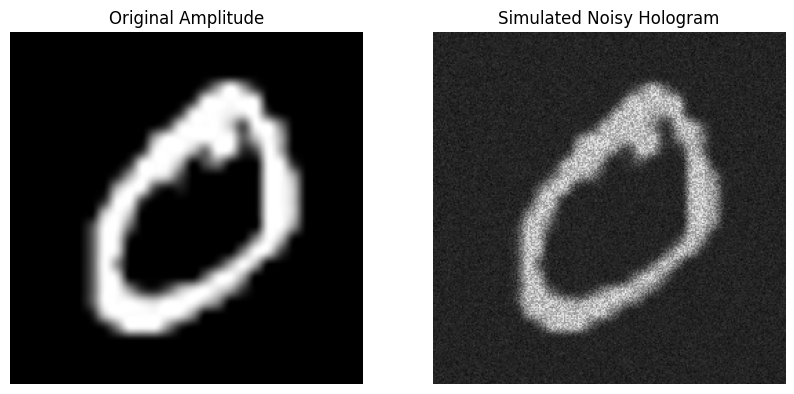

In [14]:
import torch
import math
import random

def simulate_qiup_hologram(amplitude,
                           rp=0.5,
                           ri=0.5,
                           gamma=0.5,
                           noise_std_list=[0.01, 0.05, 0.1, 0.5]):

    phi = torch.rand_like(amplitude) * (2 * math.pi)
    rs = amplitude

    base_holo = rp**2 + rs**2 + 2 * rp * rs * ri * gamma * torch.cos(phi)

    picked_std = random.choice(noise_std_list)   

    created_noise = picked_std * torch.randn_like(base_holo)

    noisy_holo = base_holo + created_noise

    noisy_holo = (noisy_holo - noisy_holo.min()) / (noisy_holo.max() - noisy_holo.min() + 1e-8)

    return noisy_holo


import matplotlib.pyplot as plt

img = Image.open("smooth0.png").convert("L")

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

amp = transform(img)
noisy_list = simulate_qiup_hologram(amp) 
noisy_holo = noisy_list[0]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Amplitude")
plt.imshow(amp.squeeze().cpu().numpy(), cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Simulated Noisy Hologram")
plt.imshow(noisy_holo.squeeze().cpu().numpy(), cmap='gray')
plt.axis('off')

plt.show()
